IMPORTING LIBRARIES

In [1]:
#Importing Libraris

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
#Loading The Dataset

df = pd.read_csv(r"C:\Users\Sirlaw\Desktop\Data Science Internship Project\Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,"11,999,139.00",43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,"11,755,881.00",42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,"12,086,707.00",43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,"12,285,693.00",43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,"12,256,762.00",44.68,Rural


In [3]:
#Inspecting data Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [4]:
#Checking Missing Values
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [5]:
#Examinig Empty rows
df[df.isnull().all(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#Removing empty rows 
df = df.dropna(how="all").copy()

In [7]:
#Checking Shape
df.shape

(740, 7)

In [8]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
#Cleaning Columns names
df.columns = df.columns.str.strip()

In [10]:
#Checking
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [11]:
#Categorical unique values
df["Frequency"].unique()

<StringArray>
[' Monthly', 'Monthly']
Length: 2, dtype: str

In [12]:
#Cleaning All Categorical Columns
categorical_cols = ["Region", "Frequency", "Area"]

for col in categorical_cols:
    df[col] = df[col].str.strip()

In [13]:
#Rechecking
df["Frequency"].unique()

<StringArray>
['Monthly']
Length: 1, dtype: str

In [14]:
#Convert Date properly
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

In [15]:
#Check
df["Date"].dtype

dtype('<M8[us]')

In [16]:
#check for invalid Date
df["Date"].isna().sum()

np.int64(0)

In [17]:
#Sorting Dataset for Time serires
df = df.sort_values(
    ["Region", "Area", "Date"]
).reset_index(drop=True)

In [18]:
#Check
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 40.6 KB


In [19]:
#Descriptive Stat
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.00,740.00,740.00
mean,2019-12-12 18:36:58.378378,11.79,"7,204,460.03",42.63
min,2019-05-31 00:00:00,0.00,"49,420.00",13.33
25%,2019-08-31 00:00:00,4.66,"1,190,404.50",38.06
50%,2019-11-30 00:00:00,8.35,"4,744,178.50",41.16
75%,2020-03-31 00:00:00,15.89,"11,275,489.50",45.51
max,2020-06-30 00:00:00,76.74,"45,777,509.00",72.57
std,NaN,10.72,"8,087,988.43",8.11


In [ ]:
# Descriptive Stat For Important Variables
df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.00,740.00,740.00
mean,11.79,"7,204,460.03",42.63
std,10.72,"8,087,988.43",8.11
min,0.00,"49,420.00",13.33
25%,4.66,"1,190,404.50",38.06
50%,8.35,"4,744,178.50",41.16
75%,15.89,"11,275,489.50",45.51
max,76.74,"45,777,509.00",72.57


In [21]:
#Understanding the regions
df["Region"].nunique()

28

In [22]:
#Check Regions
df["Region"].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
       'Chandigarh',     'Chhattisgarh',            'Delhi',
              'Goa',          'Gujarat',          'Haryana',
 'Himachal Pradesh',  'Jammu & Kashmir',        'Jharkhand',
        'Karnataka',           'Kerala',   'Madhya Pradesh',
      'Maharashtra',        'Meghalaya',           'Odisha',
       'Puducherry',           'Punjab',        'Rajasthan',
           'Sikkim',       'Tamil Nadu',        'Telangana',
          'Tripura',    'Uttar Pradesh',      'Uttarakhand',
      'West Bengal']
Length: 28, dtype: str

In [23]:
#Rural Vs Urban
df["Area"].value_counts()

Area
Urban    381
Rural    359
Name: count, dtype: int64

In [24]:
#Checking time Period
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

Start: 2019-05-31 00:00:00
End: 2020-06-30 00:00:00


In [25]:
#Covid-19 Variable indicator
df["COVID_Period"] = np.where(
    df["Date"] >= "2020-03-01",
    "COVID",
    "Pre-COVID"
)

In [26]:
#Check
df["COVID_Period"].value_counts()

COVID_Period
Pre-COVID    536
COVID        204
Name: count, dtype: int64

In [27]:
#Creating Important Variables
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Year_Month"] = df["Date"].dt.to_period("M")

EXPLORATORY DATA ANALYSIS(EDA)

In [28]:
#Unemployment by Month
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

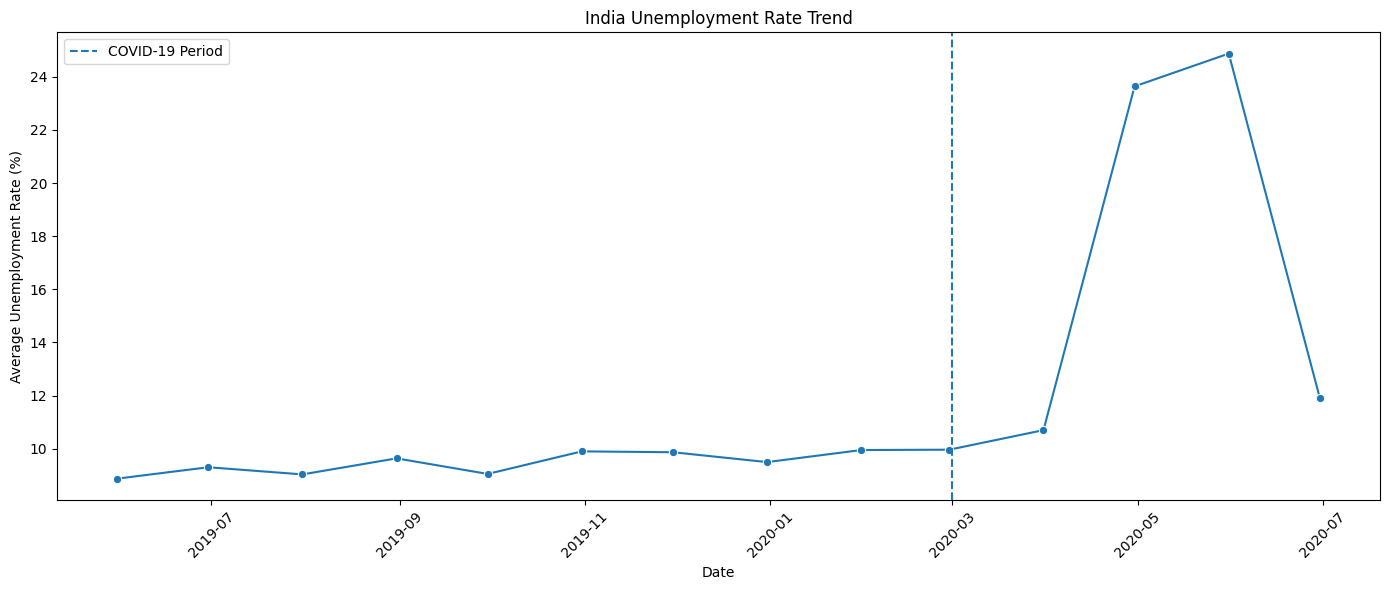

In [29]:
#Visuals
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_unemployment,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--",
    label="COVID-19 Period"
)

plt.title("India Unemployment Rate Trend")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

 **Key Insight**

India’s unemployment rate remained relatively stable at around **9–10% throughout 2019 and early 2020**, indicating a persistent but moderate level of unemployment. However, the trend changed sharply during the **COVID-19 period**, with unemployment rising from about **10.7% in April 2020 to 23.6% in May and 24.8% in June**.

The sharp increase highlights the **significant disruption COVID-19 caused to employment and economic activity**. By July 2020, the unemployment rate fell considerably to approximately **11.9%**, suggesting an early recovery as economic activities gradually resumed.

**Business takeaway**:COVID-19 created a major short-term shock to India’s labour market, with unemployment more than doubling at its peak before beginning to recover


In [30]:
#Monthly UNemployment Rate Table
monthly_summary = (
    df.groupby("Date")
    .agg(
        Avg_Unemployment=(
            "Estimated Unemployment Rate (%)",
            "mean"
        ),
        Avg_Employed=(
            "Estimated Employed",
            "mean"
        ),
        Avg_Labour_Participation=(
            "Estimated Labour Participation Rate (%)",
            "mean"
        )
    )
    .reset_index()
)

monthly_summary

,Date,Avg_Unemployment,Avg_Employed,Avg_Labour_Participation
0,2019-05-31,8.87,"7,410,148.44",43.90
1,2019-06-30,9.30,"7,358,641.57",43.75
2,2019-07-31,9.03,"7,404,425.31",43.71
3,2019-08-31,9.64,"7,539,815.19",43.65
4,2019-09-30,9.05,"7,739,463.96",44.30
5,2019-10-31,9.90,"7,298,382.40",44.00
6,2019-11-30,9.87,"7,273,660.64",44.11
7,2019-12-31,9.50,"7,377,387.83",43.67
8,2020-01-31,9.95,"7,677,344.42",44.05
9,2020-02-29,9.96,"7,603,996.28",43.72


In [31]:
#Highest Unemployment Month
monthly_summary.loc[
    monthly_summary["Avg_Unemployment"].idxmax()
]

Date                        2020-05-31 00:00:00
Avg_Unemployment                          24.88
Avg_Employed                       5,879,363.02
Avg_Labour_Participation                  38.50
Name: 12, dtype: object

In [32]:
#Five worst Unemployment Month
monthly_summary.sort_values(
    "Avg_Unemployment",
    ascending=False
).head()

,Date,Avg_Unemployment,Avg_Employed,Avg_Labour_Participation
12,2020-05-31,24.88,"5,879,363.02",38.50
11,2020-04-30,23.64,"5,283,319.90",35.14
13,2020-06-30,11.90,"7,387,008.66",40.55
10,2020-03-31,10.70,"7,516,581.13",43.08
9,2020-02-29,9.96,"7,603,996.28",43.72


In [33]:
#Average Employment
monthly_employment = (
    df.groupby("Date")["Estimated Employed"]
    .mean()
    .reset_index()
)

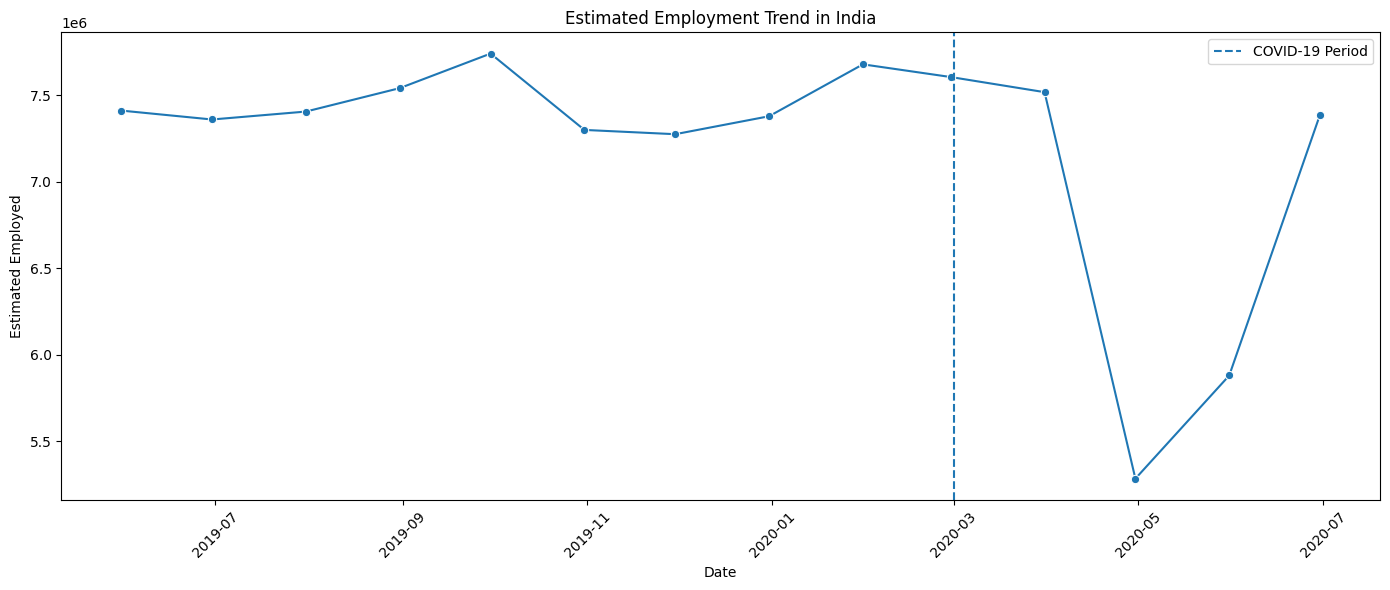

In [34]:
#plot of employment
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_employment,
    x="Date",
    y="Estimated Employed",
    marker="o"
)

plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--",
    label="COVID-19 Period"
)

plt.title("Estimated Employment Trend in India")
plt.xlabel("Date")
plt.ylabel("Estimated Employed")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insight

India’s estimated employment remained relatively stable at around **7.3–7.7 million** throughout 2019 and early 2020. However, employment declined sharply during the **COVID-19 period**, falling from approximately **7.5 million in April 2020 to 5.3 million in May**—the lowest point on the chart.

Employment began to recover in June and rose strongly to approximately **7.4 million by July 2020**, indicating a rapid rebound as economic activities gradually resumed.

**Business takeaway:** The COVID-19 shock caused a severe short-term contraction in employment, but the strong recovery by July suggests that employment was highly responsive to the reopening of economic activities.


In [35]:
#Analysis of Labour Participation
monthly_lpr = (
    df.groupby("Date")
    ["Estimated Labour Participation Rate (%)"]
    .mean()
    .reset_index()
)

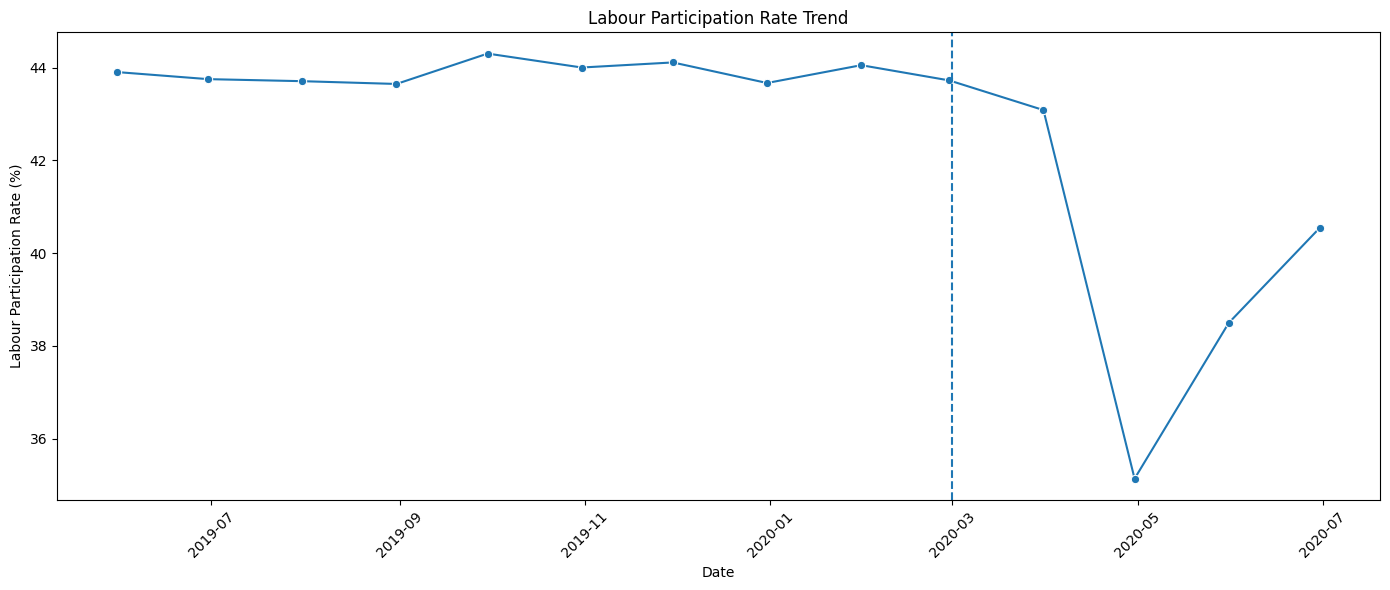

In [36]:
#Plot
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_lpr,
    x="Date",
    y="Estimated Labour Participation Rate (%)",
    marker="o"
)

plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--"
)

plt.title("Labour Participation Rate Trend")
plt.xlabel("Date")
plt.ylabel("Labour Participation Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insight

India’s labour participation rate remained relatively stable at around **43–44% throughout 2019 and early 2020**. However, it declined sharply during the COVID-19 period, falling from approximately **43.1% in April 2020 to 35.1% in May**, representing a major contraction in labour market participation.

The rate began recovering in June and reached approximately **40.5% by July 2020**, but remained below its pre-COVID level.

**Business takeaway:** COVID-19 significantly reduced labour force participation, reflecting widespread disruption to employment opportunities and economic activity, with recovery beginning as restrictions eased.


In [ ]:
#Percentage change in Unemployment Increase
pre_covid = df.loc[
    df["COVID_Period"] == "Pre-COVID",
    "Estimated Unemployment Rate (%)"
].mean()

covid = df.loc[
    df["COVID_Period"] == "COVID",
    "Estimated Unemployment Rate (%)"
].mean()

change = covid - pre_covid

percentage_change = (change / pre_covid) * 100

print("Pre-COVID unemployment:", pre_covid)
print("COVID unemployment:", covid)
print("Absolute change:", change)
print("Percentage change:", percentage_change)

Pre-COVID unemployment: 9.509533582089553
COVID unemployment: 17.774362745098042
Absolute change: 8.26482916300849
Percentage change: 86.91098350580133


In [ ]:
#Compare Employment Before anf After COVID-19
pre_employment = df.loc[
    df["COVID_Period"] == "Pre-COVID",
    "Estimated Employed"
].mean()

covid_employment = df.loc[
    df["COVID_Period"] == "COVID",
    "Estimated Employed"
].mean()

employment_change = covid_employment - pre_employment

employment_pct_change = (
    employment_change / pre_employment
) * 100

print("Pre-COVID employment:", pre_employment)
print("COVID employment:", covid_employment)
print("Change:", employment_change)
print("Percentage change:", employment_pct_change)

Pre-COVID employment: 7466027.869402985
COVID employment: 6517203.338235294
Change: -948824.5311676906
Percentage change: -12.708558657490823


In [ ]:
#Comparing Labour Participation
pre_lpr = df.loc[
    df["COVID_Period"] == "Pre-COVID",
    "Estimated Labour Participation Rate (%)"
].mean()

covid_lpr = df.loc[
    df["COVID_Period"] == "COVID",
    "Estimated Labour Participation Rate (%)"
].mean()

print("Pre-COVID LPR:", pre_lpr)
print("COVID LPR:", covid_lpr)
print("Change:", covid_lpr - pre_lpr)

Pre-COVID LPR: 43.886119402985074
COVID LPR: 39.33004901960784
Change: -4.556070383377232


In [ ]:
#Rural Vs Urban Impact of COVID-19
area_summary = (
    df.groupby(["Area", "COVID_Period"])
    .agg(
        Avg_Unemployment=(
            "Estimated Unemployment Rate (%)",
            "mean"
        ),
        Avg_Employment=(
            "Estimated Employed",
            "mean"
        ),
        Avg_LPR=(
            "Estimated Labour Participation Rate (%)",
            "mean"
        )
    )
    .reset_index()
)

area_summary

,Area,COVID_Period,Avg_Unemployment,Avg_Employment,Avg_LPR
0,Rural,COVID,16.18,"9,299,948.99",41.58
1,Rural,Pre-COVID,8.09,"10,532,842.78",45.56
2,Urban,COVID,19.28,"3,893,471.72",37.21
3,Urban,Pre-COVID,10.84,"4,576,999.33",42.31


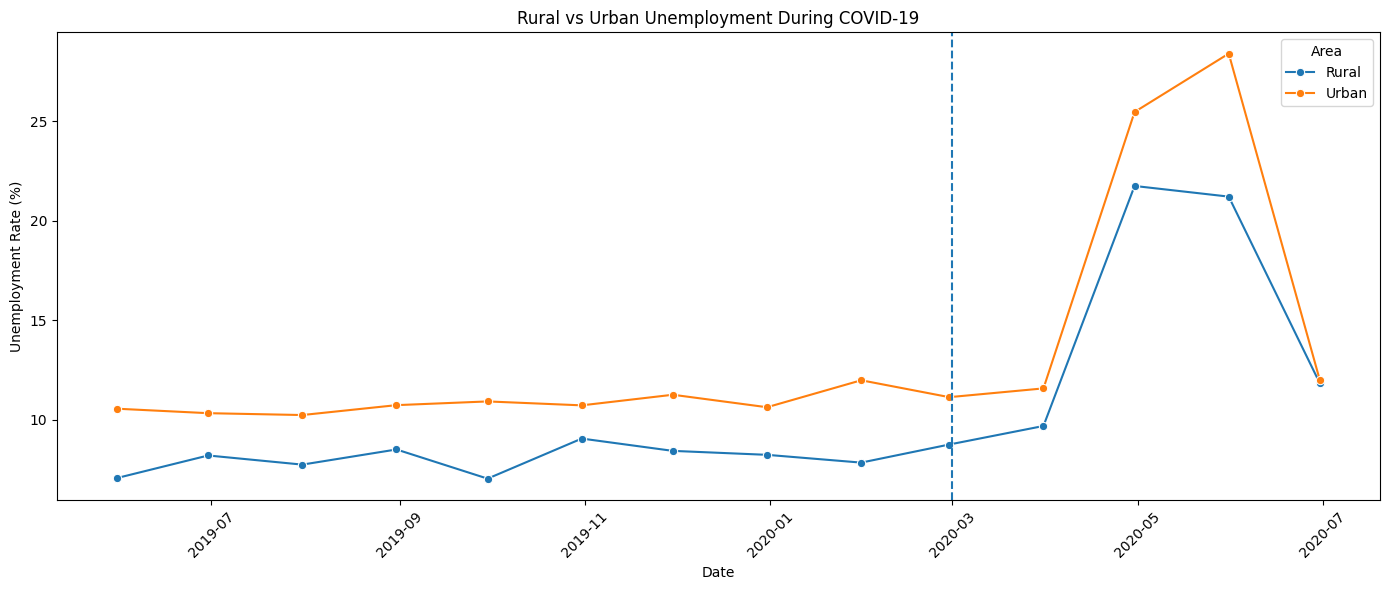

In [ ]:
#Rural Vs Urban Unemployment Rate
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Area",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--"
)

plt.title("Rural vs Urban Unemployment During COVID-19")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Key Insight

Before COVID-19, **urban unemployment consistently exceeded rural unemployment**, with urban rates generally around **10–12%** compared with **7–9%** in rural areas. During the COVID-19 shock, both areas experienced a sharp increase, but the **urban unemployment rate rose more dramatically**, reaching approximately **28.3% in June 2020**, compared with **21.2% in rural areas**.

By July 2020, unemployment in both areas fell sharply to around **12%**, indicating a rapid recovery as economic activities resumed.

**Business takeaway:** COVID-19 had a **stronger immediate impact on urban employment**, likely reflecting greater exposure to lockdown-sensitive sectors and disruptions in non-agricultural economic activity.


In [ ]:
#Calculate Rural Vs Urban COVID-19 Impact
area_covid = (
    df.groupby(["Area", "COVID_Period"])
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .unstack()
)

area_covid 

COVID_Period,COVID,Pre-COVID
Area,,
Rural,16.18,8.09
Urban,19.28,10.84


In [ ]:
#Change
area_covid["Change"] = (
    area_covid["COVID"]
    - area_covid["Pre-COVID"]
)

area_covid["Percentage_Change"] = (
    area_covid["Change"]
    / area_covid["Pre-COVID"]
) * 100

area_covid

COVID_Period,COVID,Pre-COVID,Change,Percentage_Change
Area,,,,
Rural,16.18,8.09,8.09,99.90
Urban,19.28,10.84,8.43,77.79


In [ ]:
#Unemployment By State
region_unemployment = (
    df.groupby("Region")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_unemployment

Region
Tripura            28.35
Haryana            26.28
Jharkhand          20.59
Bihar              18.92
Himachal Pradesh   18.54
Delhi              16.50
Jammu & Kashmir    16.19
Chandigarh         15.99
Rajasthan          14.06
Uttar Pradesh      12.55
Punjab             12.03
Puducherry         10.22
Kerala             10.12
Tamil Nadu          9.28
Goa                 9.27
Chhattisgarh        9.24
West Bengal         8.12
Telangana           7.74
Maharashtra         7.56
Andhra Pradesh      7.48
Madhya Pradesh      7.41
Sikkim              7.25
Karnataka           6.68
Gujarat             6.66
Uttarakhand         6.58
Assam               6.43
Odisha              5.66
Meghalaya           4.80
Name: Estimated Unemployment Rate (%), dtype: float64

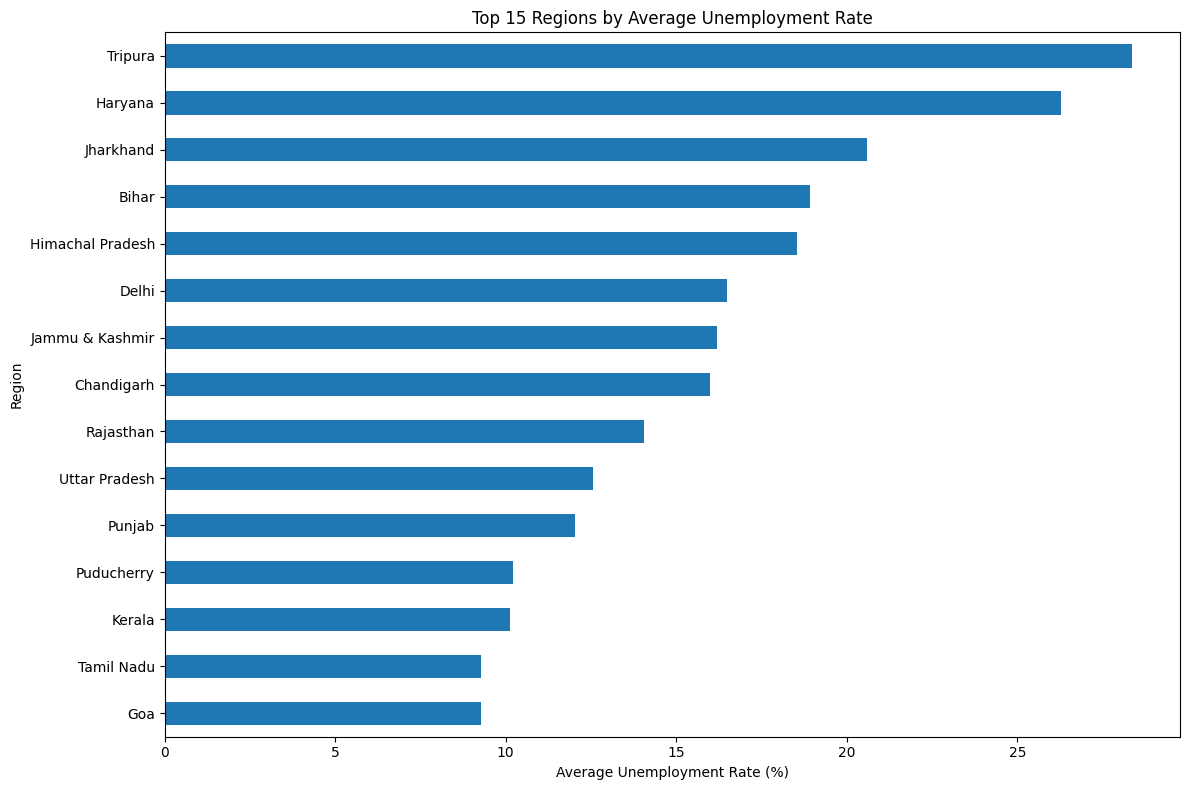

In [ ]:
#Plot top Regions
plt.figure(figsize=(12, 8))

region_unemployment.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()


In [ ]:
#COVID-19 Impact By Region
regional_covid = (
    df.groupby(["Region", "COVID_Period"])
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .unstack()
)
regional_covid["Change"] = (
    regional_covid["COVID"]
    - regional_covid["Pre-COVID"]
)
#Sort
regional_covid.sort_values(
    "Change",
    ascending=False
)

COVID_Period,COVID,Pre-COVID,Change
Region,,,
Puducherry,38.96,1.59,37.36
Tamil Nadu,25.40,2.84,22.57
Jharkhand,36.35,14.28,22.07
Bihar,31.63,13.83,17.80
Karnataka,15.28,3.23,12.05
Haryana,34.65,22.94,11.72
Kerala,17.95,6.99,10.96
Telangana,15.44,4.66,10.79
Madhya Pradesh,14.07,4.74,9.33


In [ ]:
#Most affected Regions
regional_covid.sort_values(
    "Change",
    ascending=False
).head(10)

COVID_Period,COVID,Pre-COVID,Change
Region,,,
Puducherry,38.96,1.59,37.36
Tamil Nadu,25.40,2.84,22.57
Jharkhand,36.35,14.28,22.07
Bihar,31.63,13.83,17.80
Karnataka,15.28,3.23,12.05
Haryana,34.65,22.94,11.72
Kerala,17.95,6.99,10.96
Telangana,15.44,4.66,10.79
Madhya Pradesh,14.07,4.74,9.33


In [ ]:
#Least Affected Regions
regional_covid.sort_values(
    "Change",
    ascending=True
).head(10)

COVID_Period,COVID,Pre-COVID,Change
Region,,,
Jammu & Kashmir,12.89,17.22,-4.33
Tripura,26.70,29.01,-2.31
Himachal Pradesh,17.07,19.13,-2.06
Chandigarh,14.32,16.32,-2.00
Assam,6.58,6.37,0.21
Sikkim,9.07,6.26,2.81
Uttarakhand,8.82,5.80,3.01
Meghalaya,7.07,4.00,3.07
Punjab,14.62,10.99,3.63


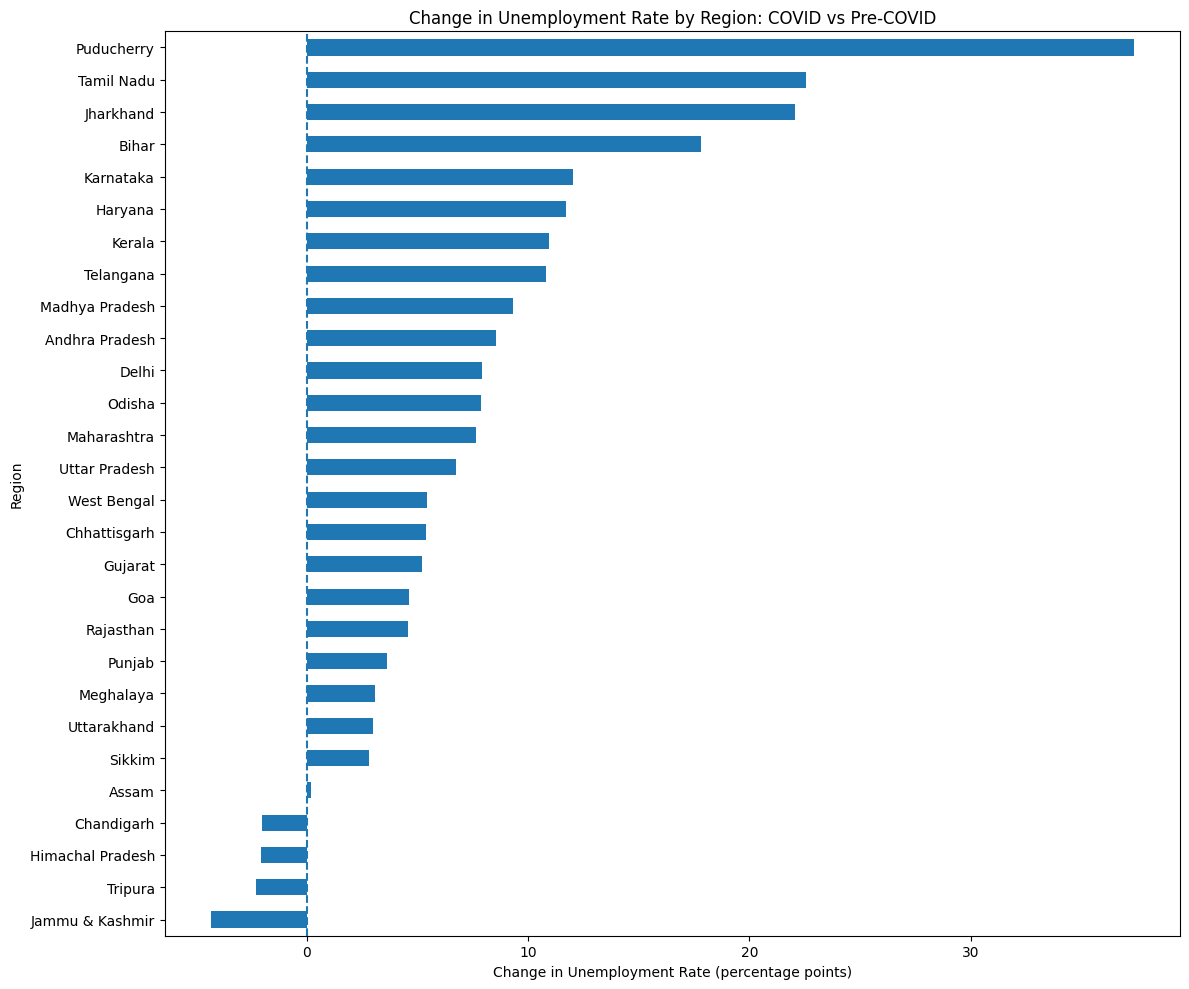

In [ ]:
#Visuals COVID-19 Impact by State
impact = regional_covid["Change"].sort_values()

plt.figure(figsize=(12, 10))

impact.plot(kind="barh")

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Change in Unemployment Rate by Region: COVID vs Pre-COVID"
)

plt.xlabel(
    "Change in Unemployment Rate (percentage points)"
)

plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [ ]:
#COVID-19 Peak By Region
covid_peak = (
    df[df["COVID_Period"] == "COVID"]
    .groupby("Region")
    ["Estimated Unemployment Rate (%)"]
    .max()
    .sort_values(ascending=False)
)

covid_peak.head(10)

Region
Puducherry         76.74
Jharkhand          70.17
Bihar              58.77
Tamil Nadu         53.19
Himachal Pradesh   50.00
Haryana            46.89
Delhi              45.78
Tripura            43.64
Punjab             40.59
Madhya Pradesh     40.49
Name: Estimated Unemployment Rate (%), dtype: float64

In [ ]:
#Specific Analysis April 2020
april_2020 = df[
    df["Date"] == "2020-04-30"
].copy()
april_2020.sort_values(
    "Estimated Unemployment Rate (%)",
    ascending=False
).head(10)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,COVID_Period,Year,Month,Month_Name,Year_Month
497,Puducherry,2020-04-30,Monthly,76.74,"68,122.00",35.54,Urban,COVID,2020,4,Apr,2020-04
485,Puducherry,2020-04-30,Monthly,74.51,"49,420.00",46.79,Rural,COVID,2020,4,Apr,2020-04
304,Jharkhand,2020-04-30,Monthly,61.48,"1,054,829.00",39.92,Urban,COVID,2020,4,Apr,2020-04
79,Bihar,2020-04-30,Monthly,58.77,"1,400,962.00",34.94,Urban,COVID,2020,4,Apr,2020-04
584,Tamil Nadu,2020-04-30,Monthly,53.19,"5,086,200.00",33.05,Rural,COVID,2020,4,Apr,2020-04
227,Haryana,2020-04-30,Monthly,46.89,"1,606,580.00",35.48,Urban,COVID,2020,4,Apr,2020-04
598,Tamil Nadu,2020-04-30,Monthly,45.55,"4,632,967.00",26.17,Urban,COVID,2020,4,Apr,2020-04
65,Bihar,2020-04-30,Monthly,45.09,"14,645,275.00",38.63,Rural,COVID,2020,4,Apr,2020-04
640,Tripura,2020-04-30,Monthly,43.64,"675,083.00",52.63,Rural,COVID,2020,4,Apr,2020-04
290,Jharkhand,2020-04-30,Monthly,41.72,"4,280,434.00",36.92,Rural,COVID,2020,4,Apr,2020-04


In [ ]:
#May 2020 Impact
may_2020 = df[
    df["Date"] == "2020-05-31"
].copy()

may_2020.sort_values(
    "Estimated Unemployment Rate (%)",
    ascending=False
).head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,COVID_Period,Year,Month,Month_Name,Year_Month
498,Puducherry,2020-05-31,Monthly,75.00,"64,538.00",31.25,Urban,COVID,2020,5,May,2020-05
305,Jharkhand,2020-05-31,Monthly,70.17,"830,347.00",40.49,Urban,COVID,2020,5,May,2020-05
291,Jharkhand,2020-05-31,Monthly,55.10,"3,315,038.00",37.03,Rural,COVID,2020,5,May,2020-05
256,Himachal Pradesh,2020-05-31,Monthly,50.00,"134,868.00",43.55,Urban,COVID,2020,5,May,2020-05
66,Bihar,2020-05-31,Monthly,47.26,"14,050,319.00",38.50,Rural,COVID,2020,5,May,2020-05
148,Delhi,2020-05-31,Monthly,45.78,"2,343,783.00",28.28,Urban,COVID,2020,5,May,2020-05
512,Punjab,2020-05-31,Monthly,40.59,"3,727,366.00",41.14,Rural,COVID,2020,5,May,2020-05
389,Madhya Pradesh,2020-05-31,Monthly,40.49,"3,879,934.00",35.49,Urban,COVID,2020,5,May,2020-05
585,Tamil Nadu,2020-05-31,Monthly,38.73,"5,768,342.00",28.60,Rural,COVID,2020,5,May,2020-05
228,Haryana,2020-05-31,Monthly,38.46,"2,013,083.00",38.27,Urban,COVID,2020,5,May,2020-05


In [ ]:
#June 2020 COVID-19 Recovery
june_2020 = df[
    df["Date"] == "2020-06-30"
].copy()
#April Vs June
recovery = (
    df[df["Date"].isin([
        pd.Timestamp("2020-04-30"),
        pd.Timestamp("2020-06-30")
    ])]
    .groupby(["Region", "Date"])
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .unstack()
)
recovery["Recovery"] = (
    recovery[pd.Timestamp("2020-04-30")]
    - recovery[pd.Timestamp("2020-06-30")]
)

recovery.sort_values(
    "Recovery",
    ascending=False
).head(10)

Date,2020-04-30 00:00:00,2020-06-30 00:00:00,Recovery
Region,,,
Puducherry,75.62,4.55,71.08
Tamil Nadu,49.37,13.49,35.88
Bihar,51.93,16.47,35.46
Jharkhand,51.60,20.45,31.14
Andhra Pradesh,24.29,3.35,20.94
Karnataka,29.15,8.52,20.63
Odisha,22.49,3.38,19.11
Tripura,39.26,23.16,16.11
Gujarat,18.97,2.98,15.99


In [ ]:
#COVID-19 Impact Variable
pre_covid_region_avg = (
    df[df["COVID_Period"] == "Pre-COVID"]
    .groupby("Region")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .rename("Pre_COVID_Regional_Avg")
)
#merge
df = df.merge(
    pre_covid_region_avg,
    on="Region",
    how="left"
)
df["COVID_Deviation"] = (
    df["Estimated Unemployment Rate (%)"]
    - df["Pre_COVID_Regional_Avg"]
)

In [ ]:
#COVID Deviation
df[df["COVID_Period"] == "COVID"].groupby(
    "Region"
)["COVID_Deviation"].mean().sort_values(
    ascending=False
)

Region
Puducherry         37.36
Tamil Nadu         22.57
Jharkhand          22.07
Bihar              17.80
Karnataka          12.05
Haryana            11.72
Kerala             10.96
Telangana          10.79
Madhya Pradesh      9.33
Andhra Pradesh      8.54
Delhi               7.93
Odisha              7.87
Maharashtra         7.66
Uttar Pradesh       6.76
West Bengal         5.44
Chhattisgarh        5.37
Gujarat             5.21
Goa                 4.60
Rajasthan           4.55
Punjab              3.63
Meghalaya           3.07
Uttarakhand         3.01
Sikkim              2.81
Assam               0.21
Chandigarh         -2.00
Himachal Pradesh   -2.06
Tripura            -2.31
Jammu & Kashmir    -4.33
Name: COVID_Deviation, dtype: float64

In [ ]:
#Correlation Analysis
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation = df[numeric_cols].corr()

correlation


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.00,-0.22,0.00
Estimated Employed,-0.22,1.00,0.01
Estimated Labour Participation Rate (%),0.00,0.01,1.00


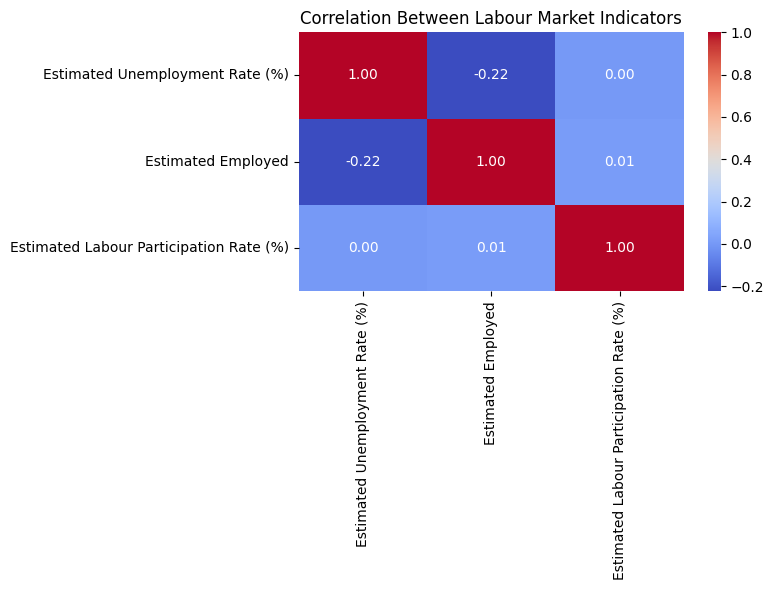

In [ ]:
#correlation Visuals
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Labour Market Indicators")

plt.tight_layout()
plt.show()

### Key Insight

The correlation analysis shows a **weak negative relationship (-0.22)** between unemployment rate and estimated employment. This suggests that higher unemployment is generally associated with lower employment, although the relationship is not particularly strong.

The correlation between **unemployment and labour participation is approximately 0.00**, while employment and labour participation show an almost negligible correlation of **0.01**. This indicates that these indicators did not move closely together in the dataset.

**Business takeaway:** Unemployment and employment show the most meaningful relationship, but the weak correlations suggest that **other economic and labour-market factors** played a significant role in explaining changes during the period.


In [ ]:
#Statistical Test:Was Unemployment Significatly Different?
pre_covid_rates = df.loc[
    df["COVID_Period"] == "Pre-COVID",
    "Estimated Unemployment Rate (%)"
]

covid_rates = df.loc[
    df["COVID_Period"] == "COVID",
    "Estimated Unemployment Rate (%)"
]
#using Welnhs t-Test
t_stat, p_value = stats.ttest_ind(
    pre_covid_rates,
    covid_rates,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -7.516809676537472
P-value: 1.1003912984705092e-12


In [ ]:
#Clear Regional Impact Measures
regional_impact = (
    df[df["COVID_Period"] == "COVID"]
    .groupby("Region")["COVID_Deviation"]
    .mean()
    .sort_values(ascending=False)
)

In [ ]:
#COVID-19 Impact Ranking
impact_table = regional_impact.reset_index()

impact_table.columns = [
    "Region",
    "Average_COVID_Deviation"
]

impact_table["Impact_Rank"] = (
    impact_table["Average_COVID_Deviation"]
    .rank(
        ascending=False,
        method="dense"
    )
)

impact_table.head(10)

,Region,Average_COVID_Deviation,Impact_Rank
0,Puducherry,37.36,1.00
1,Tamil Nadu,22.57,2.00
2,Jharkhand,22.07,3.00
3,Bihar,17.80,4.00
4,Karnataka,12.05,5.00
5,Haryana,11.72,6.00
6,Kerala,10.96,7.00
7,Telangana,10.79,8.00
8,Madhya Pradesh,9.33,9.00
9,Andhra Pradesh,8.54,10.00


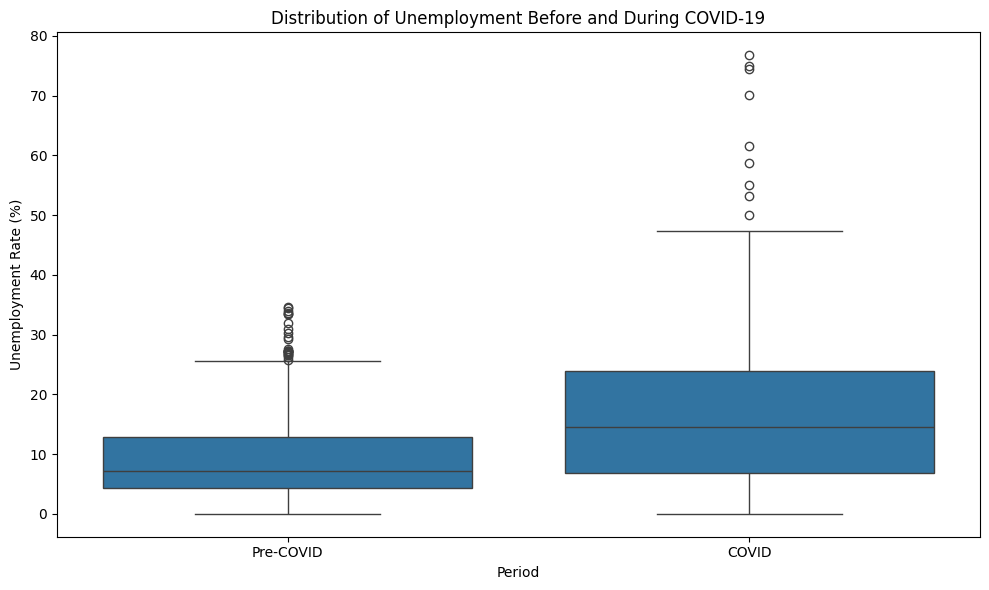

In [ ]:
#Examining Unemployment Distributions
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="COVID_Period",
    y="Estimated Unemployment Rate (%)"
)

plt.title(
    "Distribution of Unemployment Before and During COVID-19"
)

plt.xlabel("Period")
plt.ylabel("Unemployment Rate (%)")

plt.tight_layout()
plt.show()

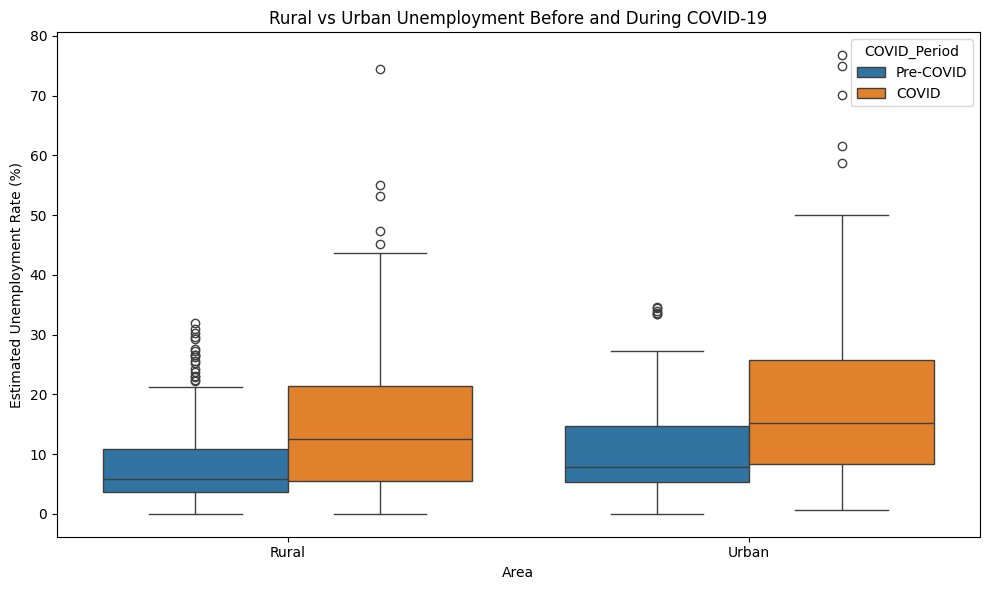

In [ ]:
#Rural/Urban Distributions
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)",
    hue="COVID_Period"
)

plt.title("Rural vs Urban Unemployment Before and During COVID-19")

plt.tight_layout()
plt.show()

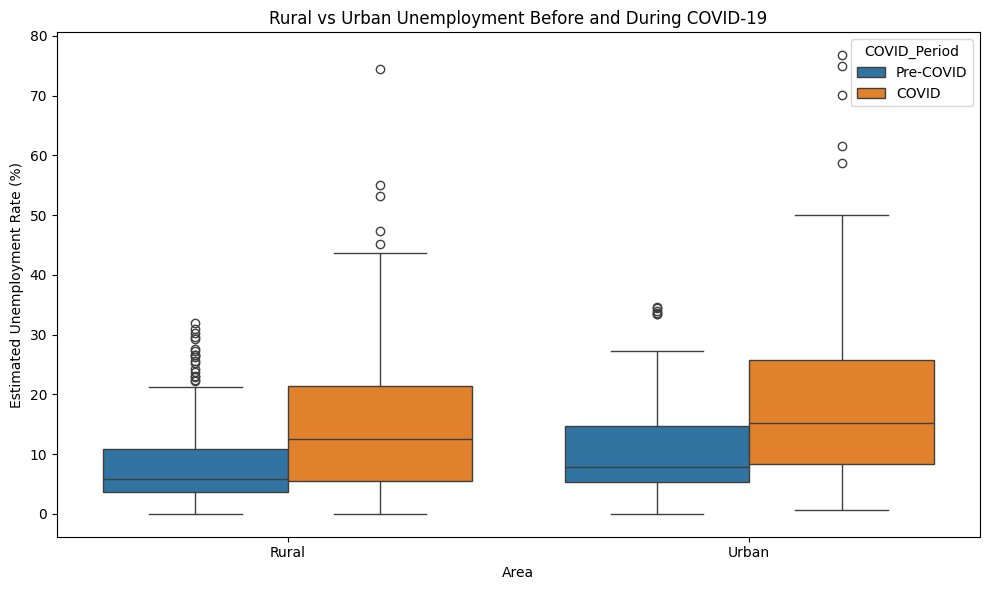

In [ ]:
#Checking Outliers
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)",
    hue="COVID_Period"
)

plt.title("Rural vs Urban Unemployment Before and During COVID-19")

plt.tight_layout()
plt.show()

In [ ]:
#Looking for Outliers
Q1 = df[
    "Estimated Unemployment Rate (%)"
].quantile(0.25)

Q3 = df[
    "Estimated Unemployment Rate (%)"
].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df["Estimated Unemployment Rate (%)"] < Q1 - 1.5 * IQR) |
    (df["Estimated Unemployment Rate (%)"] > Q3 + 1.5 * IQR)
]

outliers.shape

(35, 14)

In [ ]:
#Inspecting Outliers
outliers[
    [
        "Region",
        "Date",
        "Estimated Unemployment Rate (%)",
        "Area"
    ]
].sort_values(
    "Estimated Unemployment Rate (%)",
    ascending=False
).head(20)

,Region,Date,Estimated Unemployment Rate (%),Area
497,Puducherry,2020-04-30,76.74,Urban
498,Puducherry,2020-05-31,75.00,Urban
485,Puducherry,2020-04-30,74.51,Rural
305,Jharkhand,2020-05-31,70.17,Urban
304,Jharkhand,2020-04-30,61.48,Urban
79,Bihar,2020-04-30,58.77,Urban
291,Jharkhand,2020-05-31,55.10,Rural
584,Tamil Nadu,2020-04-30,53.19,Rural
256,Himachal Pradesh,2020-05-31,50.00,Urban
66,Bihar,2020-05-31,47.26,Rural


In [ ]:
#Creating a Clean Analytical dataset
df.to_csv(
    "cleaned_unemployment_india.csv",
    index=False
)

In [ ]:
#Final Analytical Summary Table
final_summary = (
    df.groupby(["Region", "COVID_Period"])
    .agg(
        Avg_Unemployment=(
            "Estimated Unemployment Rate (%)",
            "mean"
        ),
        Avg_Employment=(
            "Estimated Employed",
            "mean"
        ),
        Avg_Labour_Participation=(
            "Estimated Labour Participation Rate (%)",
            "mean"
        )
    )
    .reset_index()
)

final_summary.head()

,Region,COVID_Period,Avg_Unemployment,Avg_Employment,Avg_Labour_Participation
0,Andhra Pradesh,COVID,13.58,"7,587,591.25",37.74
1,Andhra Pradesh,Pre-COVID,5.04,"8,380,693.95",40.03
2,Assam,COVID,6.58,"4,780,240.71",41.81
3,Assam,Pre-COVID,6.37,"5,566,441.63",45.99
4,Bihar,COVID,31.63,"10,221,041.25",37.33


In [ ]:
#Exporting the cleaned Dataset
df.to_csv(
    "cleaned_unemployment_india.csv",
    index=False
)